# What to cover in tutorial:
- cover when you should use graphipy
- different modes: full, structure, attributes
- different metrics: show what is already implemented, show how you can use own metric function
- different types to add ts
- show disconnected graphs?

# Outline Tutorial

1. Introduction
    1. when to use graphipy
2. Importing packages 
    import different graphs here?
3. Computing examples
    1. graph structure
    2. full (maybe with remark to just features?)
    3. change distance
4. Magnitude Differences

# Graphipy Tutorial

In this tutorial you will learn the main functionalities of the `Graphipy` class. `Graphipy` can be used whenever the data for which magnitude should be computed has a graph structure. Magnitude can be computed on the graph structure only or also taking node features into account.


## Importing Packages

Before we begin, we must import the required packages. Please ensure that you have activated your virtual environment and installed the dependencies using poetry before this step (see **Dependencies** in the README).

In [144]:
# import statements for external packages
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import networkx as nx
import random

# import statements from magnipy repo
from magnipy.graphipy import Graphipy

## Computing Magnitude

The `Graphipy` class uses `NetworkX` for its graph objects. Hence, let's initialize some `NetworkX` graphs we will use throughout the tutorial. We also define some features for each graph.

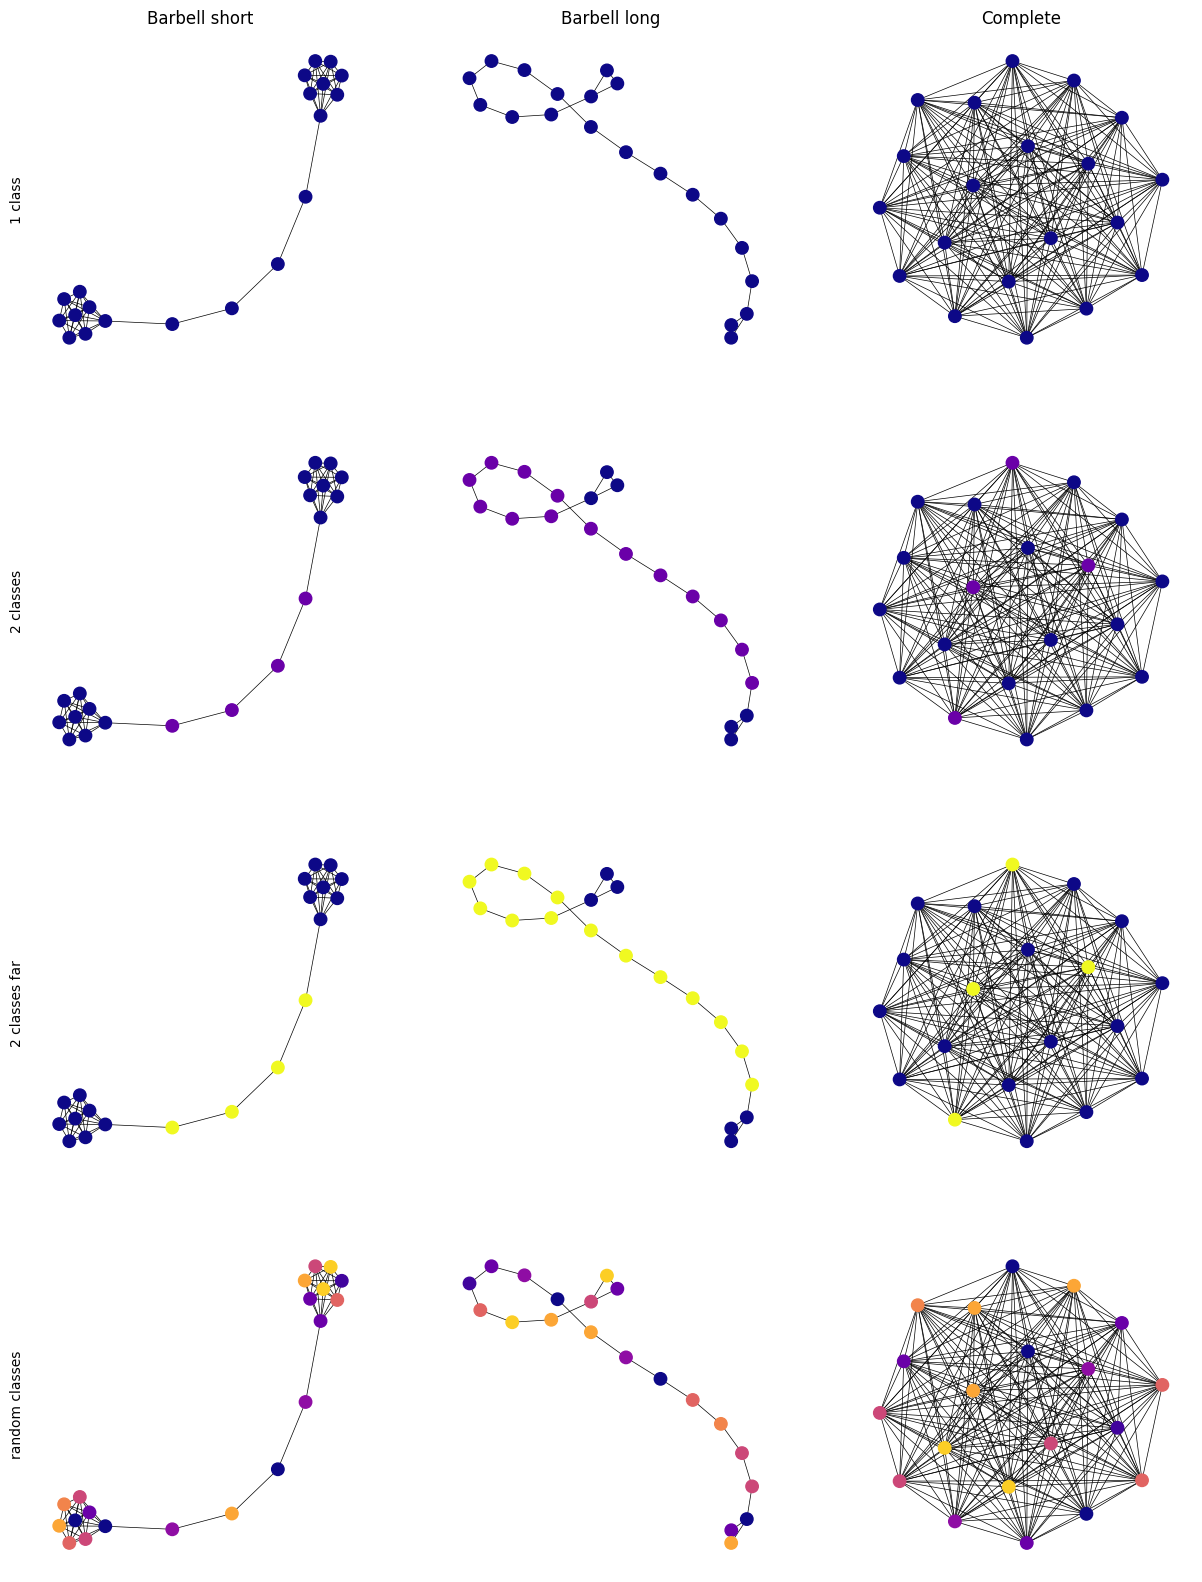

In [146]:
# initializing graphs
barbell_short = nx.barbell_graph(8, 4)
barbell_long = nx.barbell_graph(3, 14)
complete = nx.complete_graph(20)

graphs = [barbell_short, barbell_long, complete]
graphnames = ["Barbell short", "Barbell long", "Complete"]

# initializing features, need to be 2D arrays
X_1class = np.reshape(np.array([0] * 20), (-1, 1))
X_2classes_short = np.reshape(np.array([0] * 8 + [2] * 4 + [0] * 8), (-1, 1))
X_2classes_long = np.reshape(np.array([0] * 3 + [2] * 14 + [0] * 3), (-1, 1))
X_2classesfar_short = np.reshape(
    np.array([0] * 8 + [10] * 4 + [0] * 8), (-1, 1)
)
X_2classesfar_long = np.reshape(
    np.array([0] * 3 + [10] * 14 + [0] * 3), (-1, 1)
)
X_random = np.reshape(
    np.array(np.random.choice(range(10), size=20, replace=True)), (-1, 1)
)

features = [
    [X_1class] * 3,
    [X_2classes_short, X_2classes_long, X_2classes_short],
    [X_2classesfar_short, X_2classesfar_long, X_2classesfar_short],
    [X_random] * 3,
]
featurenames = [
    "1 class",
    "2 classes",
    "2 classes far",
    "random classes",
]

# plotting the graphs and features
positions = [nx.spring_layout(G) for G in graphs]

fig, ax = plt.subplots(len(features), 3, figsize=(15, 20))
for i in range(len(features)):
    for j, G in enumerate(graphs):
        nx.draw_networkx(
            G=G,
            pos=positions[j],
            ax=ax[i, j],
            with_labels=False,
            node_size=80,
            node_color=features[i][j],
            cmap="plasma",
            vmin=0,
            vmax=10,
            width=0.5,
        )
        ax[i, j].spines["top"].set_visible(False)
        ax[i, j].spines["left"].set_visible(False)
        ax[i, j].spines["right"].set_visible(False)
        ax[i, j].spines["bottom"].set_visible(False)

for j in range(len(graphs)):
    ax[0, j].set_title(graphnames[j])

for i in range(len(features)):
    ax[i, 0].set_ylabel(featurenames[i])

### Magnitude on the Graph Structure

Let us at first only look at the graph structure, so we do not take into consideration any node features. To do this, select `mode = 'structure'` while initializing the `Graphipy` objects. The magnitude computation is based on some distance between the nodes, there are different options implemented as demonstrated below.

In [150]:
# different distances for graphs found in `Graphipy`
metrics = [
    "shortest_path_distance",
    "diffusion_distance",
    "resistance_distance",
    "heat_kernel_distance",
]

graphis = {metric: [] for metric in metrics}
magnis = {metric: [] for metric in metrics}

# specifying the scales we want to compute the magnitude on
ts = np.linspace(0, 10, 100)

# initialize Graphipy objects for every metric and graph and compute the magnitude
for metric in metrics:
    for i, G in enumerate(graphs):
        graphi = Graphipy(G=G, mode="structure", metric=metric, ts=ts)
        magni, _ = graphi.get_magnitude()

        graphis[metric].append(graphi)
        magnis[metric].append(magni)

Let's plot the different magnitude functions. Note that the complete graph is the least diverse and the barbell graph with the longer handle is the most diverse. This is what we would expect from a diversity measure.

Text(0, 0.5, 'magnitude function')

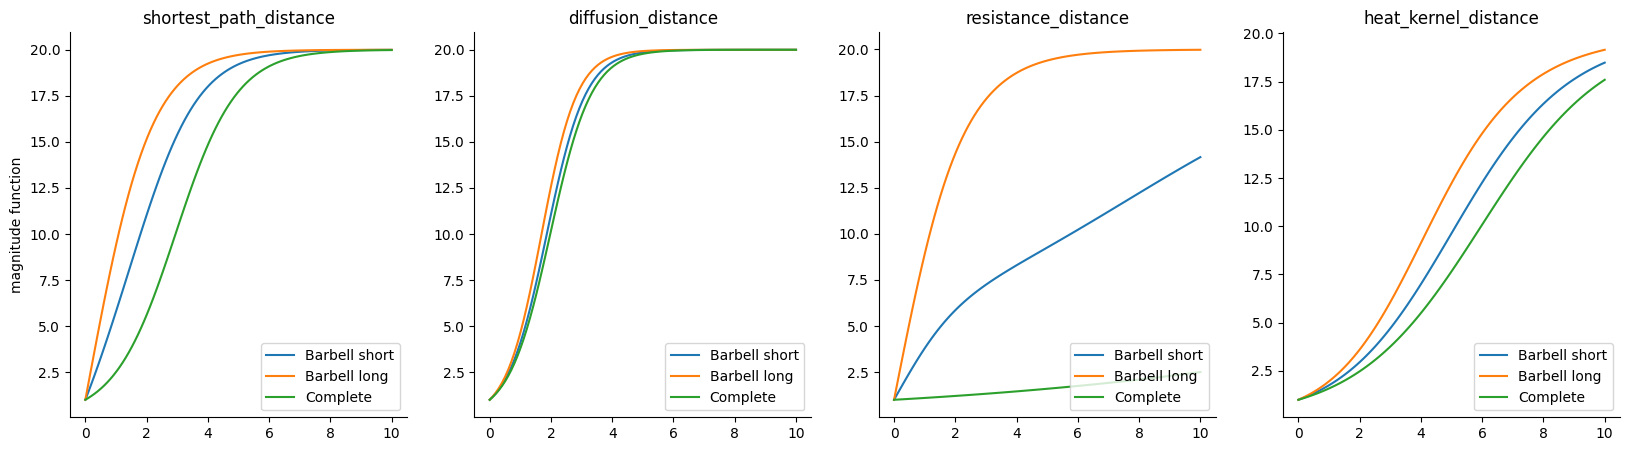

In [151]:
# plotting magnitude functions for the differnt distances
fig, ax = plt.subplots(1, len(metrics), figsize=(20, 5))

for i, metric in enumerate(metrics):
    for j in range(len(graphs)):
        ax[i].plot(ts, magnis[metric][j], label=graphnames[j])
        ax[i].legend(loc="lower right")
        ax[i].set_title(metric)
        ax[i].spines["top"].set_visible(False)
        ax[i].spines["right"].set_visible(False)

ax[0].set_ylabel("magnitude function")

We can also visualize the corresponding distance matrices of the graph nodes based on which the magnitude gets computed.

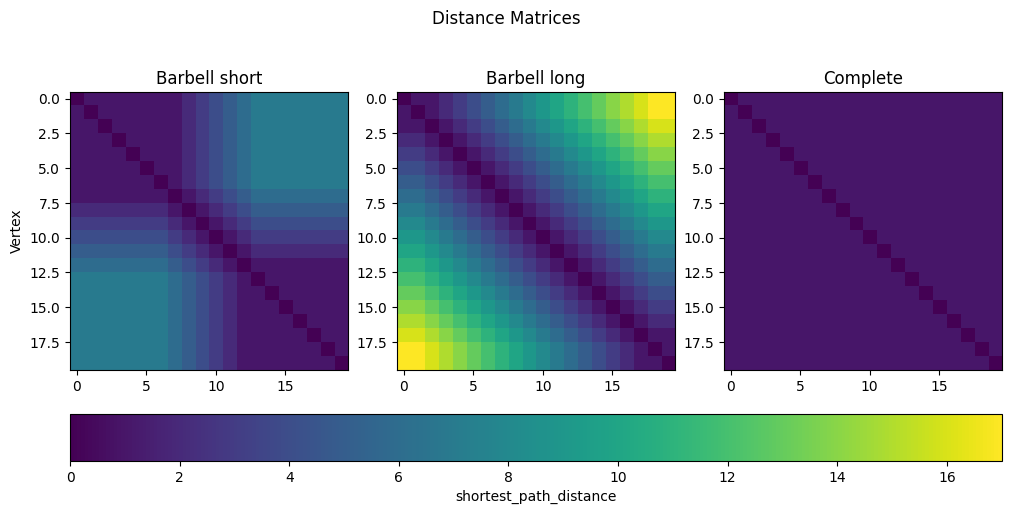

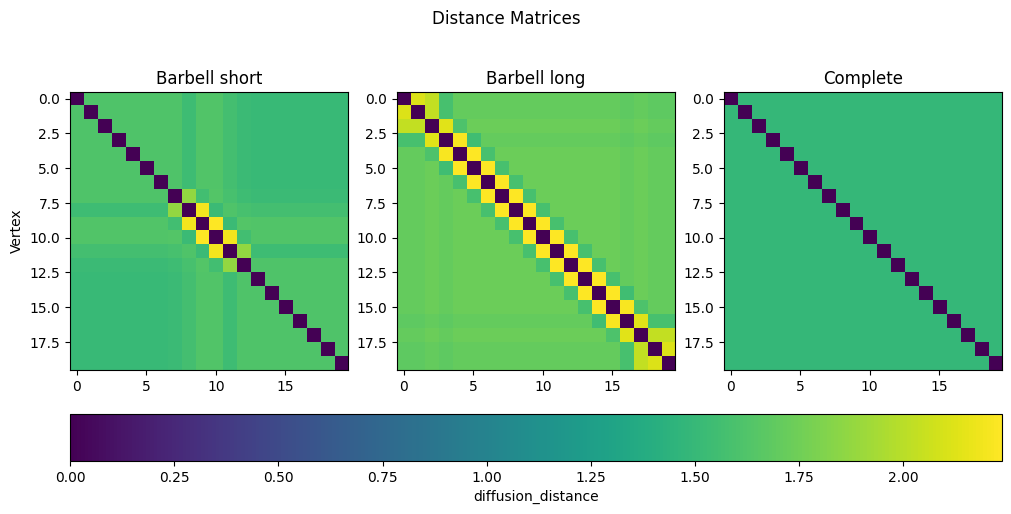

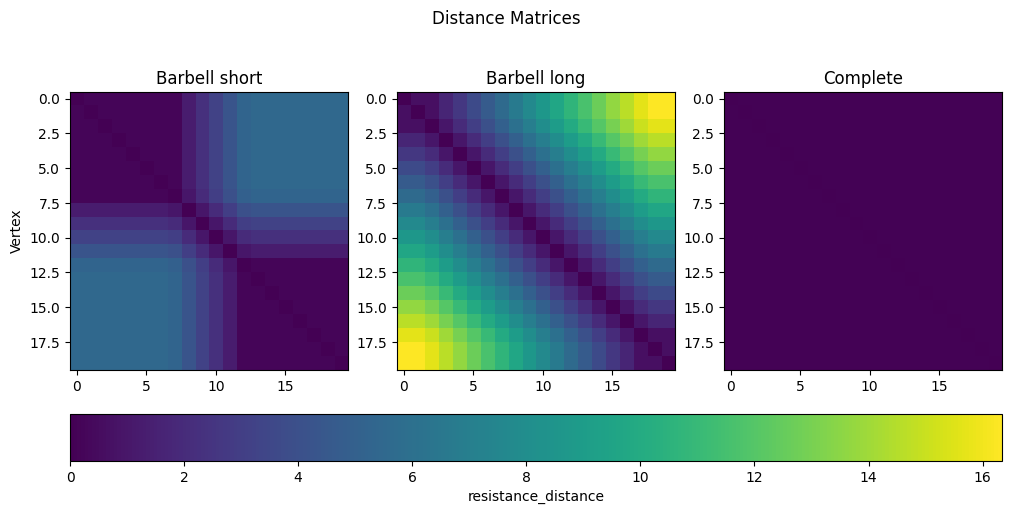

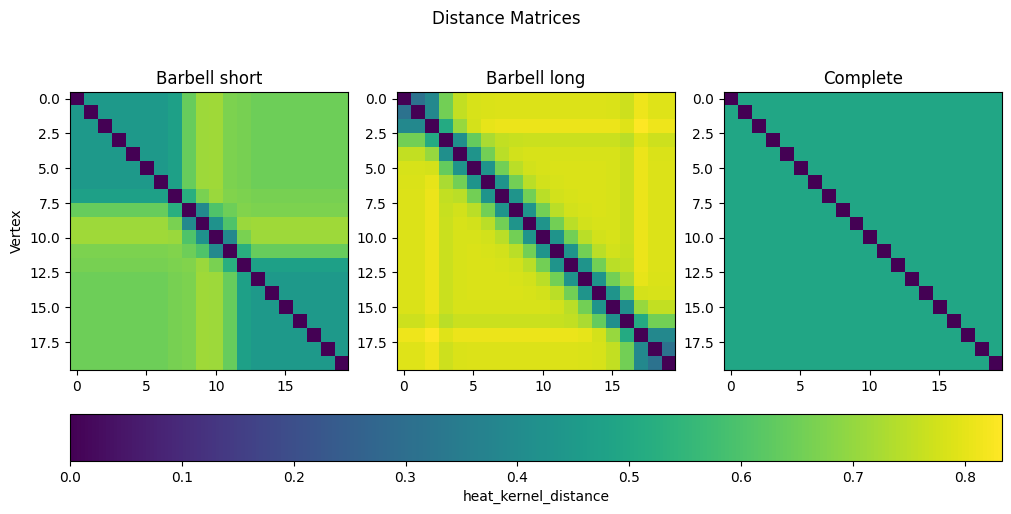

In [170]:
# plotting function
def plot_matrix_heatmaps(matrices, distance=True, metric="Euclidean Distance"):
    n = len(matrices)
    fig, axs = plt.subplots(1, n, figsize=(10, 5), constrained_layout=True)
    if distance:
        fig.suptitle("Distance Matrices")
        label = metric
    else:
        fig.suptitle("Similarity Matrices")
        label = "Similarity"

    # Find the global min and max across all datasets, ignore inf values
    vmin = min([matrices[i][0].min() for i in matrices.keys()])
    vmax = max(
        [np.ma.masked_invalid(matrices[i][0].max()) for i in matrices.keys()]
    )

    for i, name in enumerate(matrices):
        heatmap = axs[i].imshow(
            matrices[name][0], cmap="viridis", vmin=vmin, vmax=vmax
        )

        axs[i].set_title(name)

    axs[0].set_ylabel("Vertex")

    fig.colorbar(
        heatmap,
        ax=axs,
        orientation="horizontal",
        location="bottom",
        label=label,
    )
    plt.show()


for i, metric in enumerate(metrics):
    matrices = {
        graphnames[i]: graphis[metric][i].get_dist() for i in range(len(graphs))
    }
    plot_matrix_heatmaps(matrices=matrices, distance=True, metric=metric)

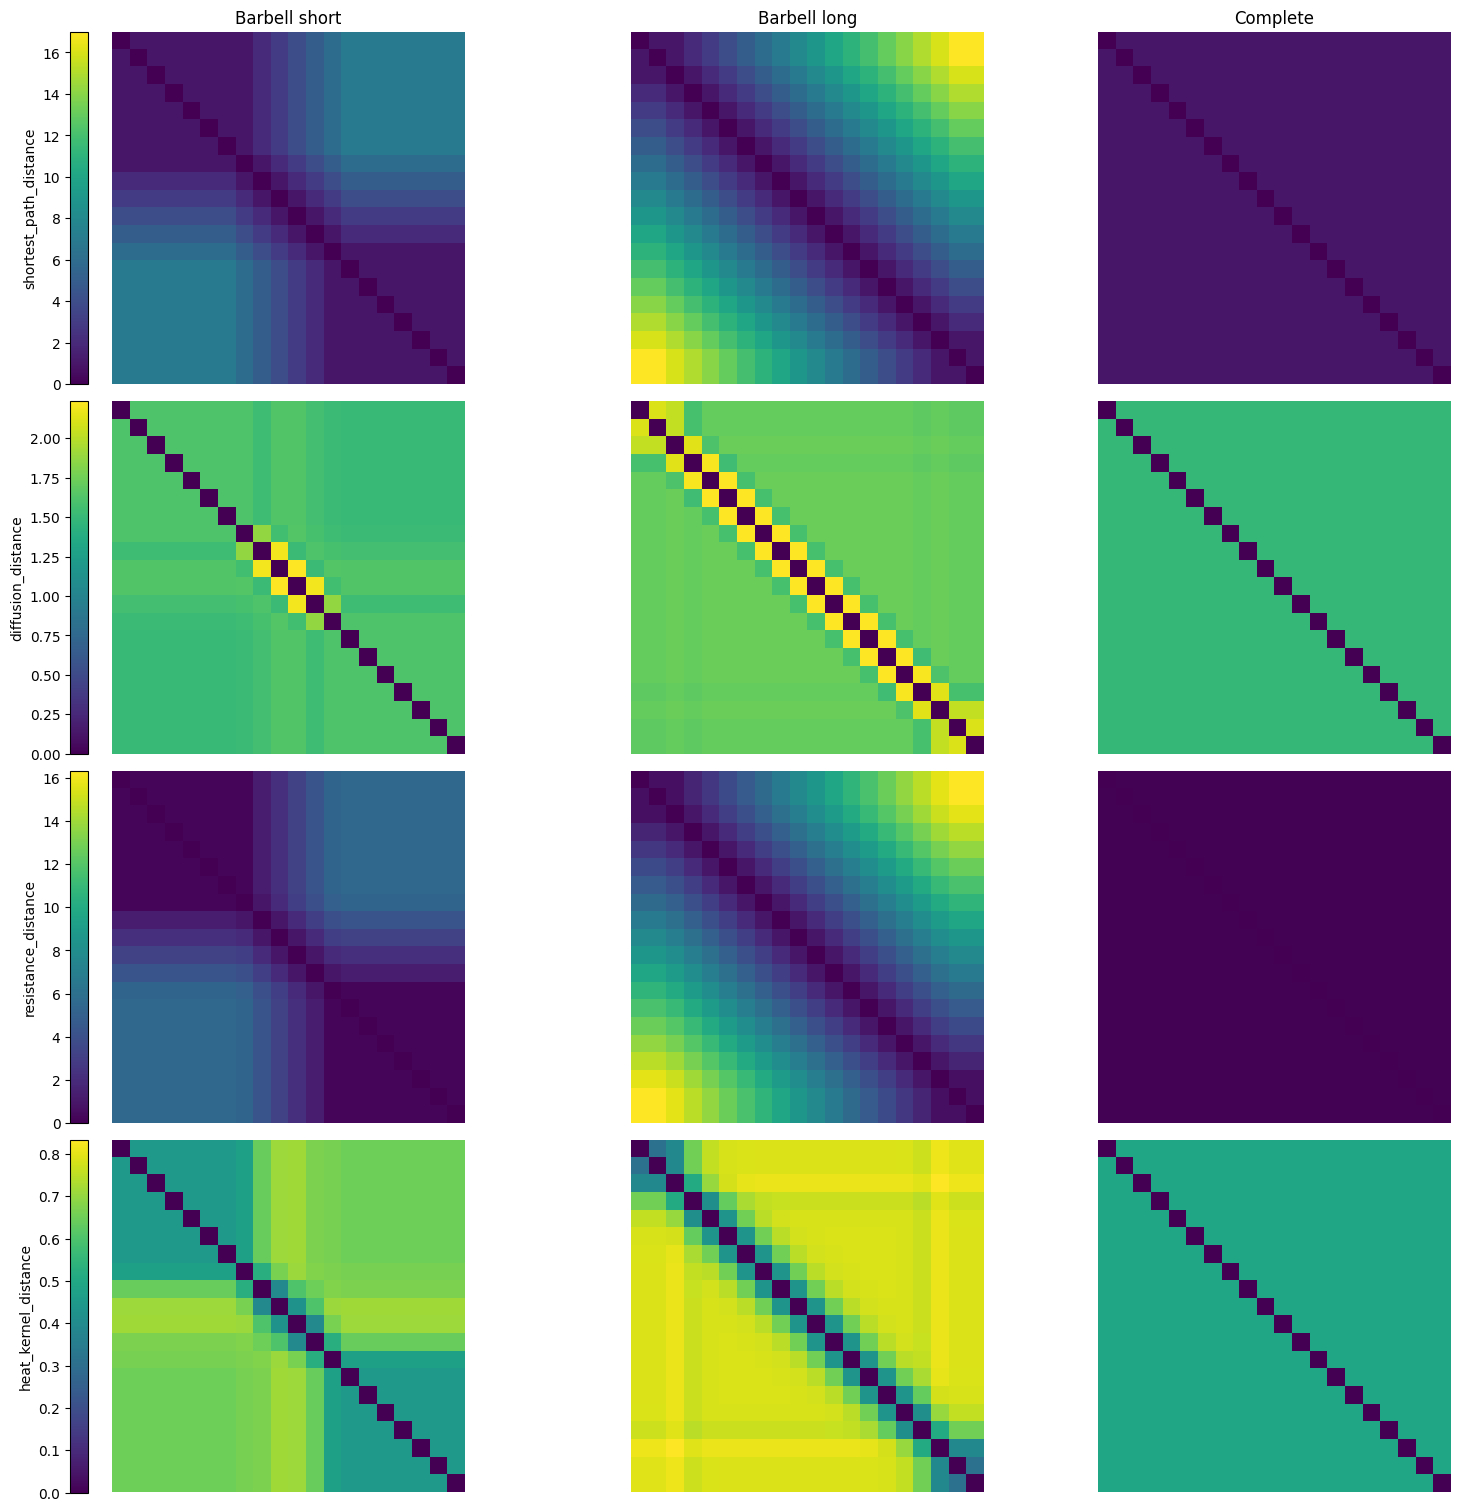

In [171]:
n_rows = len(metrics)
n_cols = len(graphs)
fig, axs = plt.subplots(
    n_rows, n_cols, figsize=(15, 15), constrained_layout=True
)

for i, metric in enumerate(metrics):
    matrices = {
        graphnames[i]: graphis[metric][i].get_dist() for i in range(len(graphs))
    }
    # Find the global min and max across all datasets, ignore inf values
    vmin = min([matrices[i][0].min() for i in matrices.keys()])
    vmax = max(
        [np.ma.masked_invalid(matrices[i][0].max()) for i in matrices.keys()]
    )

    for j, name in enumerate(matrices):
        heatmap = axs[i, j].imshow(
            matrices[name][0], cmap="viridis", vmin=vmin, vmax=vmax
        )
        axs[i, j].axis("off")
        axs[0, j].set_title(name)

    axs[i, 0].set_ylabel("Vertex")

    fig.colorbar(
        heatmap,
        ax=axs[i, 0],
        orientation="vertical",
        location="left",
        label=metric,
    )

plt.show()

### Magnitude using Features

If we have an attributed graph, we can take the node features into account for computing the magnitude.
Using `mode=full` we compute the magnitude based on the graph structure *and* the features. To be precise, we compute distances between the features based on a metric we specify when initializing the `Graphipy` object and use these as weights to our graph. The distances one can choose from can be found in `distances.py`. The similarity matrix for the magnitude computation is then based on the distances obtained by computing the geodesic distance between the nodes of the weighted graph. 

As a first example, let's look at the graphs from before but now we attribute each vertex to two classes. The first way to do this is simply by passing a matrix $X$ where each row corresponds to a node feature to our `graphipy` object.

c:\Users\haeuserm\Programming Projects\magnipy\magnipy\graphipy.py:150: UserWarning: "The graph already has features assigned to its nodes. Overriding the features with the input X."
  warnings.warn(


Text(0.5, 1.0, 'Magnitude functions with features in 2 classes')

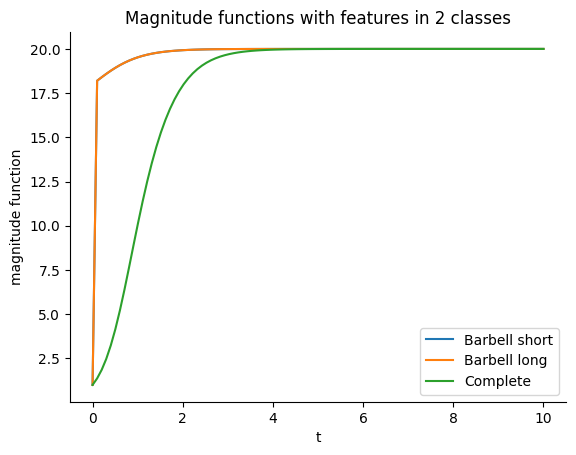

In [174]:
# initializing graphipy objects and specifying the features by passing X
ts = np.linspace(0, 10, 100)

graphi_2_shortbar = Graphipy(
    X=X_2classes_short,
    G=barbell_short,
    ts=ts,
    mode="full",
    metric="euclidean",
    method="spread",
)
graphi_2_longbar = Graphipy(
    X=X_2classes_long,
    G=barbell_long,
    ts=ts,
    mode="full",
    metric="euclidean",
    method="spread",
)
graphi_2_complete = Graphipy(
    X=X_2classes_short,
    G=complete,
    ts=ts,
    mode="full",
    metric="euclidean",
    method="spread",
)

graphi_2_shortbar.plot_magnitude_function()
graphi_2_longbar.plot_magnitude_function()
graphi_2_complete.plot_magnitude_function()

plt.legend(["Barbell short", "Barbell long", "Complete"])
plt.title("Magnitude functions with features in 2 classes")

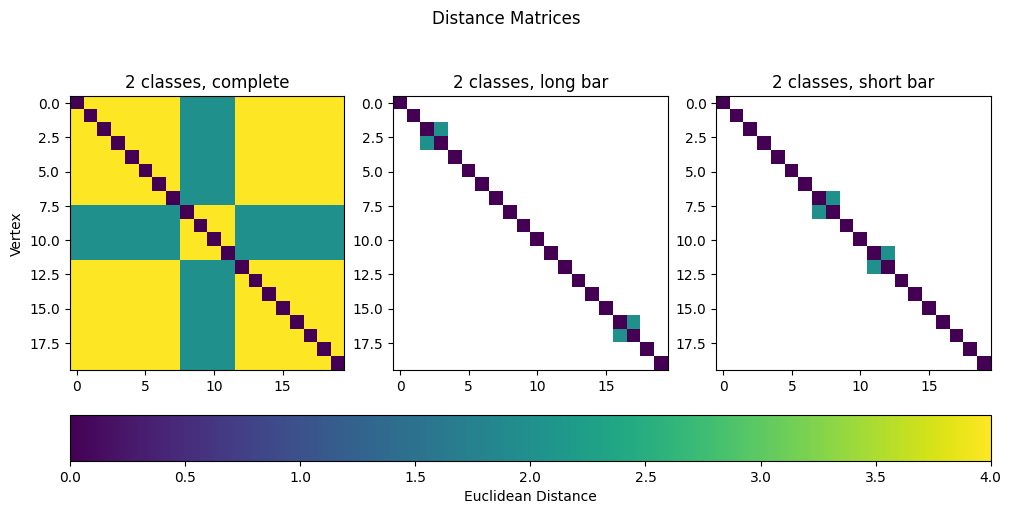

In [175]:
matrices = {
    "2 classes, complete": graphi_2_complete.get_dist(),
    "2 classes, long bar": graphi_2_longbar.get_dist(),
    "2 classes, short bar": graphi_2_shortbar.get_dist(),
}
[i for i in matrices.keys()]
plot_matrix_heatmaps(matrices=matrices, distance=True)

The other way to pass the features is to initialize the `Graphipy` object with an attributed graph. For this we use features partitioning the nodes in the same two classes but the Euclidean distance between the classes is greater, meaning the classes are farther apart from each other.

Text(0.5, 1.0, 'Magnitude functions with features in 2 far apart classes')

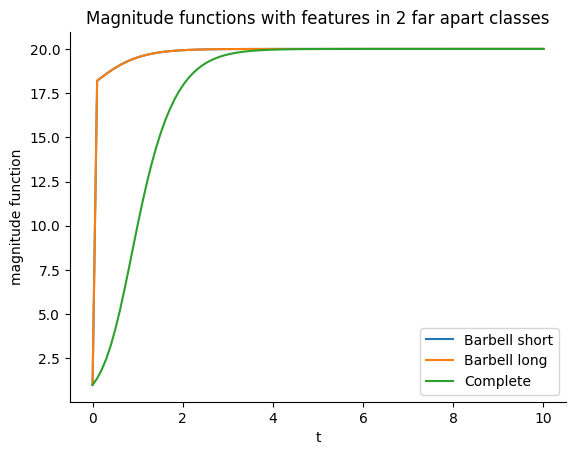

In [176]:
ts = np.linspace(0, 10, 100)

# reate copy of graphs
barbell_short_attributed = barbell_short.copy()
barbell_long_attributed = barbell_long.copy()
complete_attributed = complete.copy()

# set attribbutes of the networkx graphs, attribute name must be 'feature'
nx.set_node_attributes(
    G=barbell_short_attributed,
    values={
        i: X_2classesfar_short[i] for i in range(X_2classesfar_short.shape[0])
    },
    name="feature",
)
nx.set_node_attributes(
    G=barbell_long_attributed,
    values={
        i: X_2classesfar_long[i] for i in range(X_2classesfar_long.shape[0])
    },
    name="feature",
)
nx.set_node_attributes(
    G=complete_attributed,
    values={
        i: X_2classesfar_short[i] for i in range(X_2classesfar_short.shape[0])
    },
    name="feature",
)

# initialize graphipy object with attributed graph

graphi_2far_shortbar = Graphipy(
    G=barbell_short, ts=ts, mode="full", metric="euclidean", method="spread"
)
graphi_2far_longbar = Graphipy(
    G=barbell_long, ts=ts, mode="full", metric="euclidean", method="spread"
)
graphi_2far_complete = Graphipy(
    G=complete, ts=ts, mode="full", metric="euclidean", method="spread"
)

graphi_2far_shortbar.plot_magnitude_function()
graphi_2far_longbar.plot_magnitude_function()
graphi_2far_complete.plot_magnitude_function()

plt.legend(["Barbell short", "Barbell long", "Complete"])
plt.title("Magnitude functions with features in 2 far apart classes")

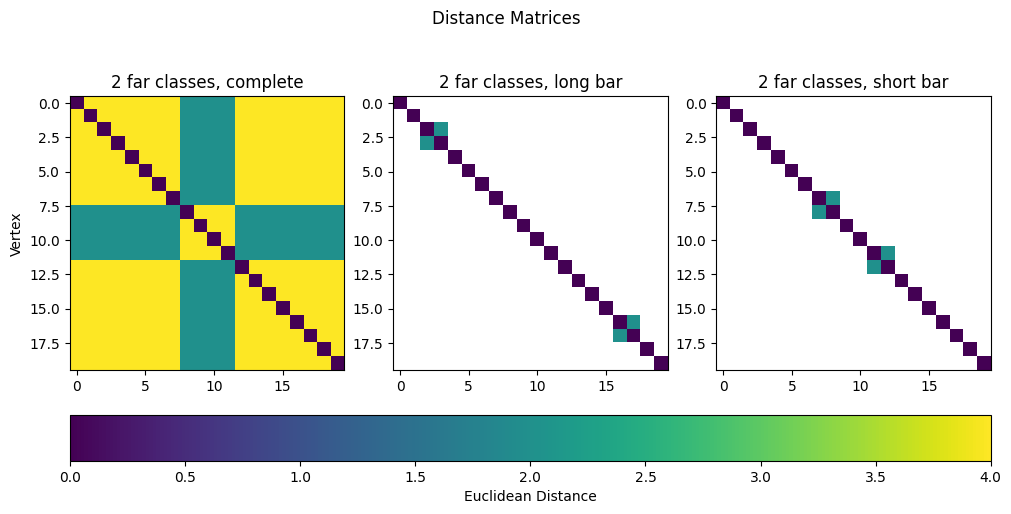

In [177]:
matrices = {
    "2 far classes, complete": graphi_2far_complete.get_dist(),
    "2 far classes, long bar": graphi_2far_longbar.get_dist(),
    "2 far classes, short bar": graphi_2far_shortbar.get_dist(),
}
[i for i in matrices.keys()]
plot_matrix_heatmaps(matrices=matrices, distance=True)

Let's also compute the magnitude for the last type of features we have, which are random features drawn from $\{0, \dots, 9\}$ with replacement.

Text(0.5, 1.0, 'Magnitude functions with random features')

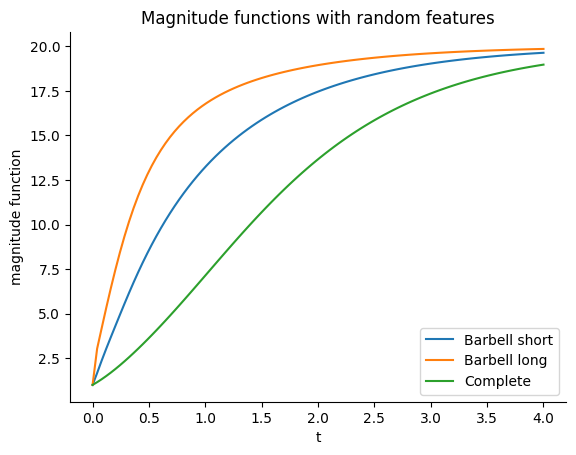

In [180]:
ts = np.linspace(0, 4, 100)

graphi_rand_shortbar = Graphipy(
    X=X_random,
    G=barbell_short,
    ts=ts,
    mode="full",
    metric="euclidean",
    method="spread",
)
graphi_rand_longbar = Graphipy(
    X=X_random,
    G=barbell_long,
    ts=ts,
    mode="full",
    metric="euclidean",
    method="spread",
)
graphi_rand_complete = Graphipy(
    X=X_random,
    G=complete,
    ts=ts,
    mode="full",
    metric="euclidean",
    method="spread",
)
graphi_rand_shortbar.plot_magnitude_function()
graphi_rand_longbar.plot_magnitude_function()
graphi_rand_complete.plot_magnitude_function()

plt.legend(["Barbell short", "Barbell long", "Complete"])
plt.title("Magnitude functions with random features")

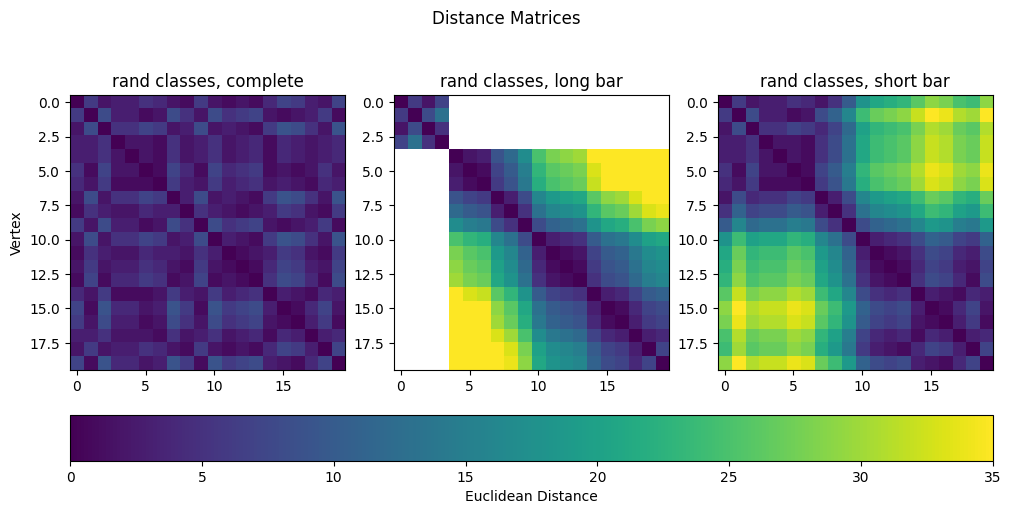

In [181]:
matrices = {
    "rand classes, complete": graphi_rand_complete.get_dist(),
    "rand classes, long bar": graphi_rand_longbar.get_dist(),
    "rand classes, short bar": graphi_rand_shortbar.get_dist(),
}
[i for i in matrices.keys()]
plot_matrix_heatmaps(matrices=matrices, distance=True)

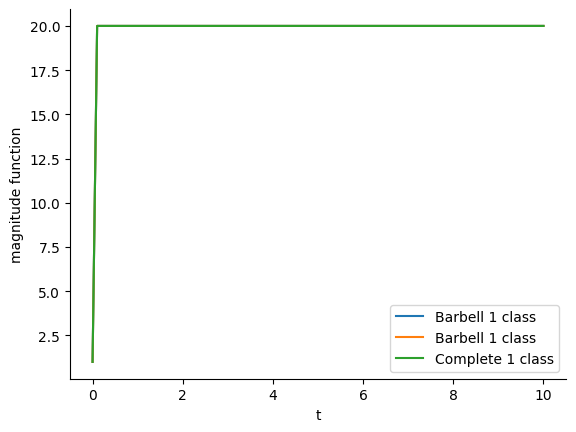

In [ ]:
graphi_1_shortbar = Graphipy(
    X=X_1class,
    G=barbell_short,
    ts=ts,
    mode="full",
    metric="euclidean",
    method="cholesky",
)
graphi_1_longbar = Graphipy(
    X=X_1class,
    G=barbell_long,
    ts=ts,
    mode="full",
    metric="euclidean",
    method="cholesky",
)
graphi_1_complete = Graphipy(
    X=X_1class,
    G=complete,
    ts=ts,
    mode="full",
    metric="euclidean",
    method="cholesky",
)

graphi_1_shortbar.plot_magnitude_function()
graphi_1_longbar.plot_magnitude_function()
graphi_1_complete.plot_magnitude_function()

plt.legend(["Barbell 1 class", "Barbell 1 class", "Complete 1 class"])

vmin: 0.0, vmax:inf


c:\Users\haeuserm\Programming Projects\magnipy\magnipyvenv\Lib\site-packages\matplotlib\colors.py:2416: RuntimeWarning: invalid value encountered in divide
  resdat /= vmax - vmin


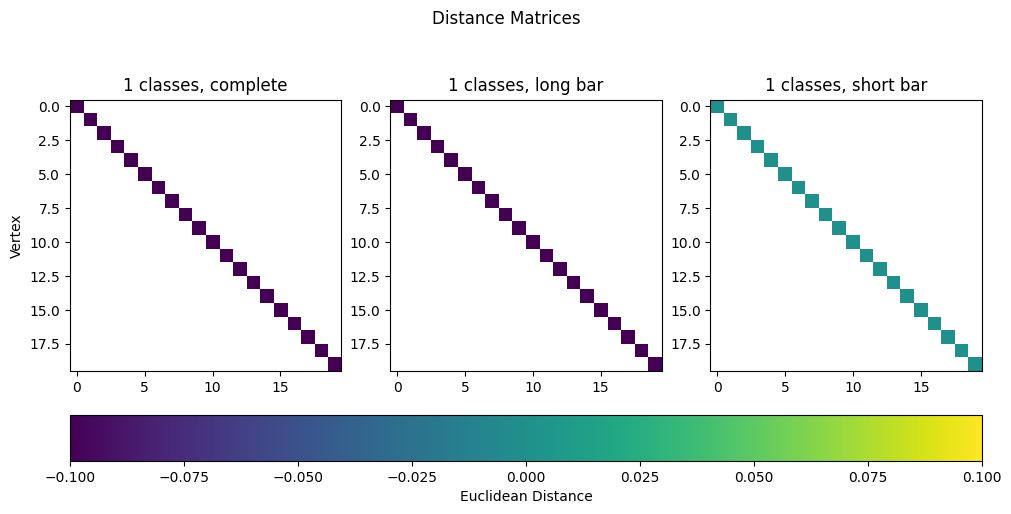

In [115]:
matrices = {
    "1 classes, complete": graphi_1_complete.get_dist(),
    "1 classes, long bar": graphi_1_longbar.get_dist(),
    "1 classes, short bar": graphi_1_shortbar.get_dist(),
}
[i for i in matrices.keys()]
plot_matrix_heatmaps(matrices=matrices, distance=True)

Another way of passing the features is by setting the node features directly in the `networkx` graph.

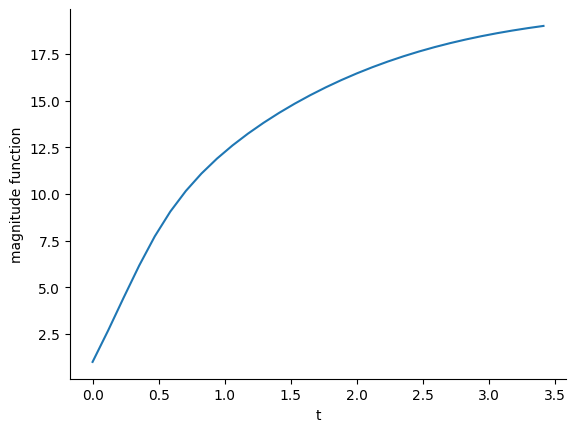

In [121]:
# reate copy of graph
barbell_short_attributed = barbell_short.copy()
# set attribbutes of the networkx graph
nx.set_node_attributes(
    G=barbell_short_attributed,
    values={i: X_3classes_short[i] for i in range(X_3classes_short.shape[0])},
    name="feature",
)
# initialize graphipy object with attributed graph
graphi_shortbar = Graphipy(
    G=barbell_short, mode="full", metric="euclidean", method="spread"
)
graphi_shortbar.plot_magnitude_function()

Another option is to use the mode `attributes` where we only use a distance between features for the magnitude. This will give the same result as creating a `Magnipy` object using the features as the data with the same choice of distance function. <br>
We use the two close classes as features. Note that the magnitude function now converges to $2$ instead of $20$ as before, since now we only have two distinct points. Also note that since the graph structure does not play a role anymore, the magnitude function for barbell short and complete coinicide since they use the same features.

Text(0.5, 1.0, 'Magnitude functions only attributes')

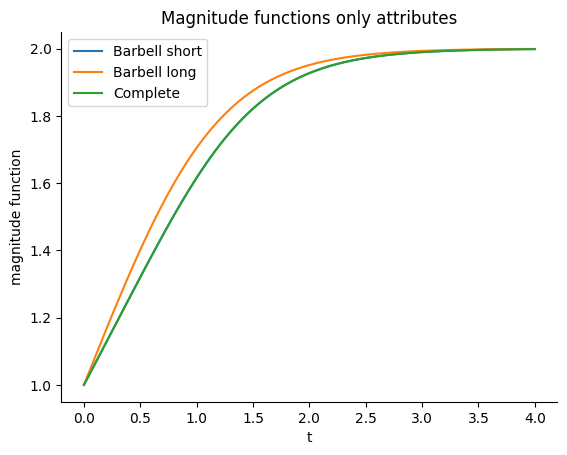

In [184]:
# initializing objects
graphi_attributes_shortbar = Graphipy(
    X=X_2classes_short,
    ts=ts,
    G=barbell_short,
    mode="attributes",
    metric="euclidean",
    method="spread",
)

graphi_attributes_longbar = Graphipy(
    X=X_2classes_long,
    ts=ts,
    G=barbell_long,
    mode="attributes",
    metric="euclidean",
    method="spread",
)

graphi_attributes_complete = Graphipy(
    X=X_2classes_short,
    ts=ts,
    G=complete,
    mode="attributes",
    metric="euclidean",
    method="spread",
)

# plotting magnitude functions
graphi_attributes_shortbar.plot_magnitude_function()
graphi_attributes_longbar.plot_magnitude_function()
graphi_attributes_complete.plot_magnitude_function()
plt.legend(["Barbell short", "Barbell long", "Complete"])
plt.title("Magnitude functions only attributes")

### Using a Custom Distance Function 

Instead of using the implemented distance functions, it is also possible to compute the magnitude using a custom distance function. Make sure that the custom distance function is compatible with the mode you are planning to use. In the example we define a distance based on the graph structure and features, so we use the mode `full`.

In [ ]:
from scipy.sparse.csgraph import shortest_path
from magnipy.magnitude.distances import distances_scipy


# our custom distance function sets the feature distance to a small positive value instead of 0 if the features are the same.
def cust_dist_no0(X=None, X2=None, G=None):
    feature_dist = distances_scipy(X, X2, metric="euclidean")
    feature_dist[feature_dist == 0] = 0.1

    Adj = nx.adjacency_matrix(G).todense()
    weighted_adjacency = Adj * feature_dist
    geodesic_distances = shortest_path(weighted_adjacency, directed=False)
    return geodesic_distances


feat_magnis = {}
feat_graphis = {}
ts = np.linspace(0, 10, 100)

# initializing the graphipy objects
graphi_2_cust_shortbar = Graphipy(
    X=X_2classes_short,
    G=barbell_short,
    mode="full",
    ts=ts,
    custom_dist_fn=cust_dist_no0,
    method="spread",
)

graphi_2_cust_longbar = Graphipy(
    X=X_2classes_long,
    G=barbell_long,
    mode="full",
    ts=ts,
    custom_dist_fn=cust_dist_no0,
    method="spread",
)

graphi_2_cust_complete = Graphipy(
    X=X_2classes_short,
    G=complete,
    mode="full",
    ts=ts,
    custom_dist_fn=cust_dist_no0,
    method="spread",
)


feat_magnis["2 classes"] = [
    graphi_2_cust_shortbar.get_magnitude(),
    graphi_2_cust_longbar.get_magnitude(),
    graphi_2_cust_complete.get_magnitude(),
]
feat_graphis["2 classes"] = [
    graphi_2_cust_shortbar,
    graphi_2_cust_longbar,
    graphi_2_cust_complete,
]


graphi_2far_cust_shortbar = Graphipy(
    X=X_2classesfar_short,
    G=barbell_short,
    mode="full",
    ts=ts,
    custom_dist_fn=cust_dist_no0,
    method="spread",
)

graphi_2far_cust_longbar = Graphipy(
    X=X_2classesfar_long,
    G=barbell_long,
    mode="full",
    ts=ts,
    custom_dist_fn=cust_dist_no0,
    method="spread",
)

graphi_2far_cust_complete = Graphipy(
    X=X_2classesfar_short,
    G=complete,
    mode="full",
    ts=ts,
    custom_dist_fn=cust_dist_no0,
    method="spread",
)

feat_magnis["2 classes far"] = [
    graphi_2far_cust_shortbar.get_magnitude(),
    graphi_2far_cust_longbar.get_magnitude(),
    graphi_2far_cust_complete.get_magnitude(),
]
feat_graphis["2 classes far"] = [
    graphi_2far_cust_shortbar,
    graphi_2far_cust_longbar,
    graphi_2far_cust_complete,
]

graphi_1_cust_shortbar = Graphipy(
    X=X_1class,
    G=barbell_short,
    mode="full",
    ts=ts,
    custom_dist_fn=cust_dist_no0,
    method="spread",
)

graphi_1_cust_longbar = Graphipy(
    X=X_1class,
    G=barbell_long,
    mode="full",
    ts=ts,
    custom_dist_fn=cust_dist_no0,
    method="spread",
)

graphi_1_cust_complete = Graphipy(
    X=X_1class,
    G=complete,
    mode="full",
    ts=ts,
    custom_dist_fn=cust_dist_no0,
    method="spread",
)

feat_magnis["1 class"] = [
    graphi_1_cust_shortbar.get_magnitude(),
    graphi_1_cust_longbar.get_magnitude(),
    graphi_1_cust_complete.get_magnitude(),
]
feat_graphis["1 class"] = [
    graphi_1_cust_shortbar,
    graphi_1_cust_longbar,
    graphi_1_cust_complete,
]

graphi_rand_cust_shortbar = Graphipy(
    X=X_random,
    G=barbell_short,
    mode="full",
    ts=ts,
    custom_dist_fn=cust_dist_no0,
    method="spread",
)

graphi_rand_cust_longbar = Graphipy(
    X=X_random,
    G=barbell_long,
    mode="full",
    ts=ts,
    custom_dist_fn=cust_dist_no0,
    method="spread",
)

graphi_rand_cust_complete = Graphipy(
    X=X_random,
    G=complete,
    mode="full",
    ts=ts,
    custom_dist_fn=cust_dist_no0,
    method="spread",
)

feat_magnis["random classes"] = [
    graphi_rand_cust_shortbar.get_magnitude(),
    graphi_rand_cust_longbar.get_magnitude(),
    graphi_rand_cust_complete.get_magnitude(),
]
feat_graphis["random classes"] = [
    graphi_rand_cust_shortbar,
    graphi_rand_cust_longbar,
    graphi_rand_cust_complete,
]

c:\Users\haeuserm\Programming Projects\magnipy\magnipy\graphipy.py:150: UserWarning: "The graph already has features assigned to its nodes. Overriding the features with the input X."
  warnings.warn(


Text(0, 0.5, 'magnitude function')

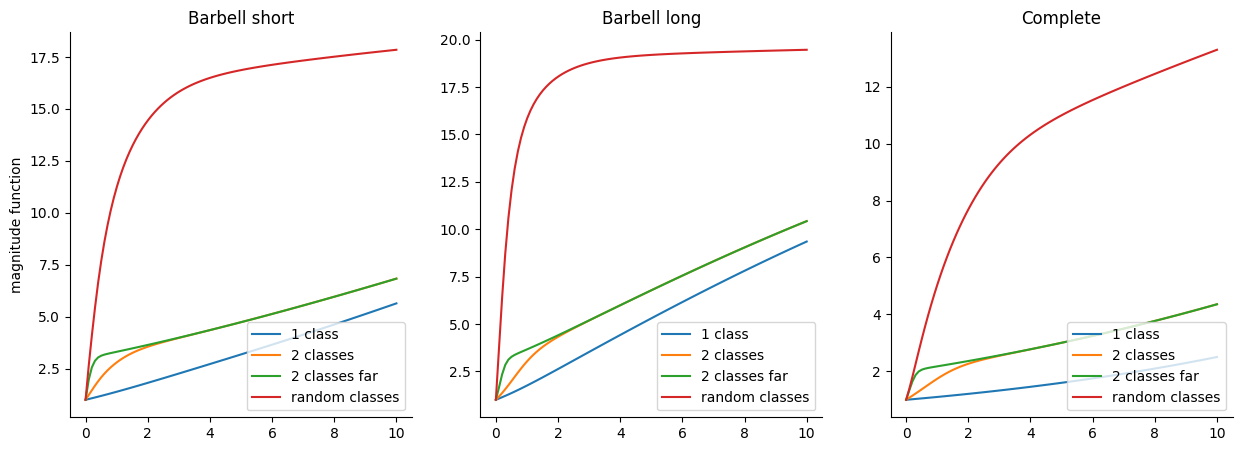

In [189]:
# plotting magnitude functions
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for i in range(len(graphs)):
    for j, feature in enumerate(featurenames):
        ax[i].plot(ts, feat_magnis[feature][i][0], label=feature)
        ax[i].legend(loc="lower right")
        ax[i].set_title(graphnames[i])
        ax[i].spines["top"].set_visible(False)
        ax[i].spines["right"].set_visible(False)
ax[0].set_ylabel("magnitude function")

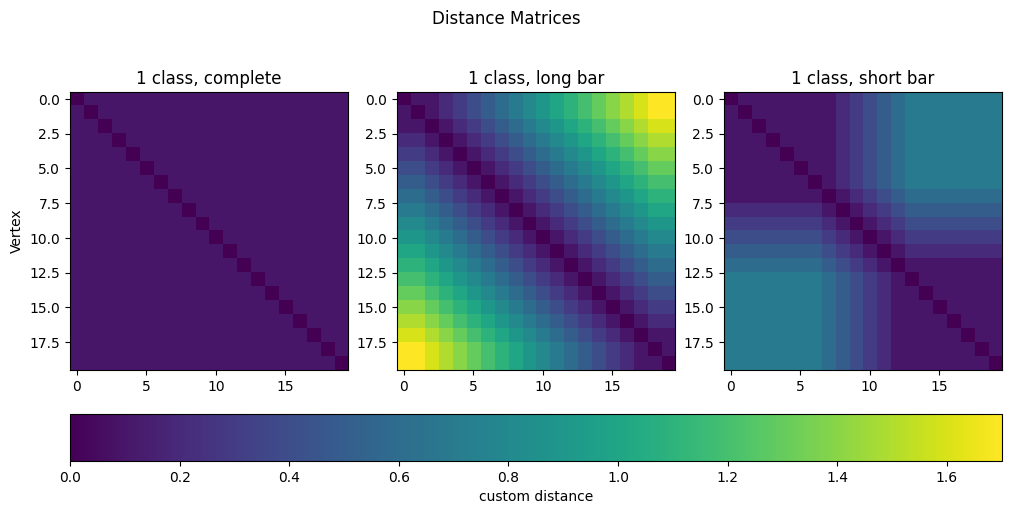

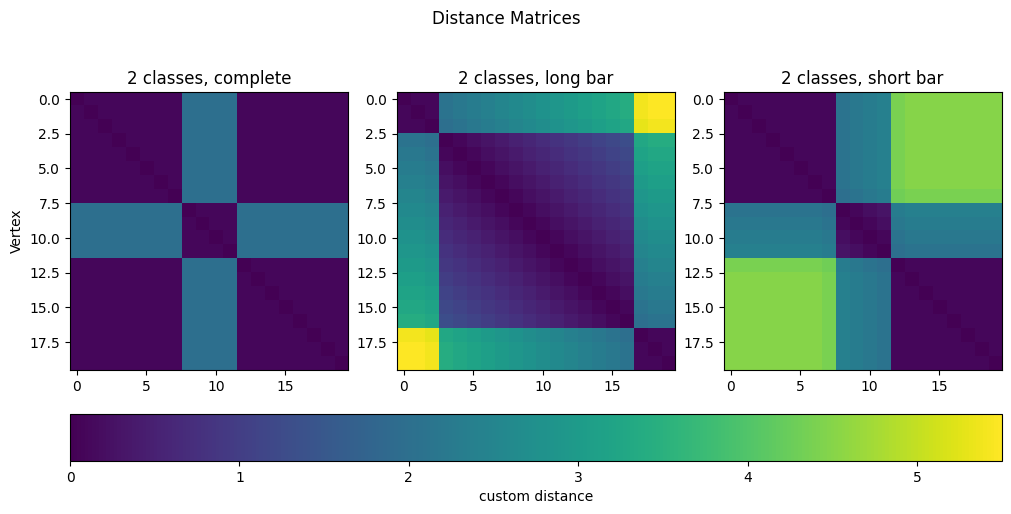

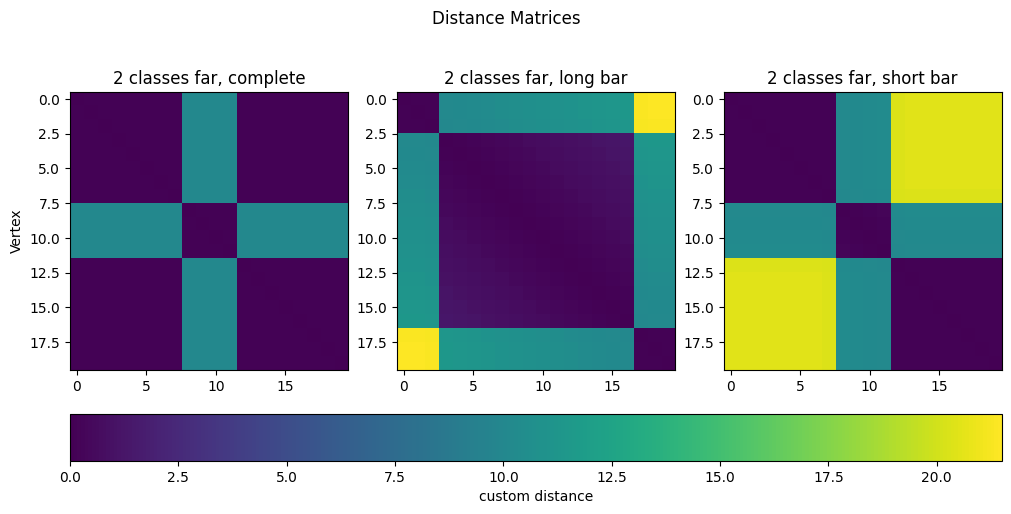

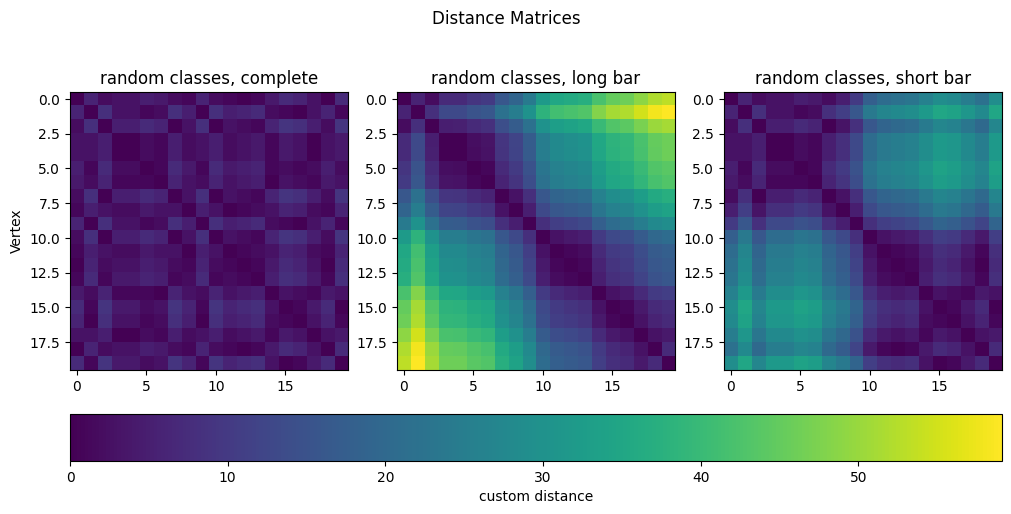

In [190]:
# plotting distance matrices
for i, feature in enumerate(featurenames):
    matrices = {
        f"{feature}, complete": feat_graphis[feature][2].get_dist(),
        f"{feature}, long bar": feat_graphis[feature][1].get_dist(),
        f"{feature}, short bar": feat_graphis[feature][0].get_dist(),
    }
    plot_matrix_heatmaps(
        matrices=matrices, distance=True, metric="custom distance"
    )

## Computing Differences in Magnitude

Computing the difference in magnitude can be insightful for comparing the difference in diversity between two spaces. The `Graphipy` package includes a `_substract` method which can be used for this task. <lb>
One appplication can be found in 'Geometry-aware Edge Pooling for Graph Neural Networks' where the difference in diversity is used to decide which edge to collapse in order to find a structure preserving pooling method. <br>
The example shows the difference in magnitude for the two classes and the two classes further apart.

In [195]:
# computing the differences in magnitude
diff_2_shortbar, diff_ts_shortbar = graphi_2far_cust_shortbar._subtract(
    other=graphi_2_cust_shortbar
)
diff_2_longbar, diff_ts_longbar = graphi_2far_cust_longbar._subtract(
    other=graphi_2_cust_longbar
)
diff_2_complete, diff_ts_complete = graphi_2far_cust_complete._subtract(
    other=graphi_2_cust_complete
)

Plotting the differences between the magnitude function shows that for small $t$ values we see a higher diversity in the magnitude of the graph with its nodes in the clusters farther apart. For larger $t$ values the larger distance does not play a role anymore and hence the difference between the magnitude goes to $0$.

Text(0.5, 0, 't')

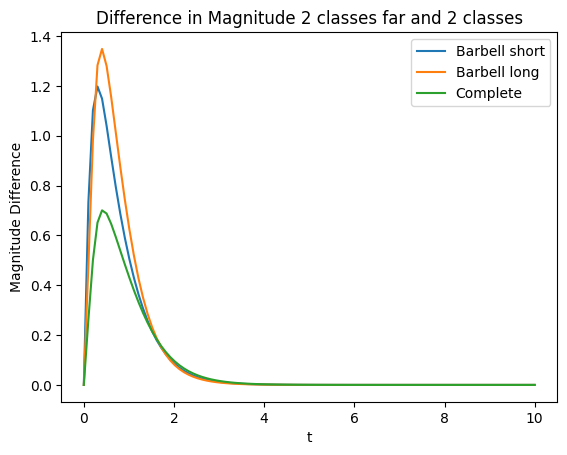

In [196]:
plt.plot(diff_ts_shortbar, diff_2_shortbar, label="Barbell short")
plt.plot(diff_ts_longbar, diff_2_longbar, label="Barbell long")
plt.plot(diff_ts_complete, diff_2_complete, label="Complete")

plt.legend(loc="upper right")
plt.title("Difference in Magnitude 2 classes far and 2 classes")
plt.ylabel("Magnitude Difference")
plt.xlabel("t")